In [1]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

import desc
!pip show desc-opt

Name: desc-opt
Version: 0.17.0
Summary: Computes, analyzes and optimizes 3D MHD equilibria for stellarators and tokamaks
Home-page: https://github.com/PlasmaControl/DESC/
Author: Daniel Dudt, Rory Conlin, Dario Panici, Kaya Unalmis, Yigit Gunsur Elmacioglu, Rahul Gaur, Patrick Kim, Egemen Kolemen
Author-email: PlasmaControl@princeton.edu
License: MIT
Location: /home/imogen/anaconda3/envs/desc-0170/lib/python3.14/site-packages
Editable project location: /home/imogen/DESC
Requires: colorama, diffrax, equinox, h5py, interpax, jax, jax-finufft, matplotlib, mpmath, netcdf4, numpy, nvgpu, optax, orthax, plotly, psutil, pylatexenc, quadax, scikit-image, scipy, sympy, termcolor
Required-by: 


### compute2D：二维平衡计算

本 notebook 使用 DESC 计算二维托卡马克平衡。平衡由四类输入共同决定：安全因子剖面、压强剖面、最外层磁面形状和最外层环向磁通。

请按步骤运行需要的代码块；每一步运行前先确认相应代码块参数。

### 第一步：设置安全因子和压强剖面

请选择一种输入方式：

1. 解析剖面：在 `1.1代码块` 中设置 `Qorders`、`Qparams`、`Porders`、`Pparams`。
2. 离散数据：在 `1.2代码块` 中读取 MATLAB 文件，文件需包含一维数组 `Rho`、`Safety`、`Pressure`。

运行 `1.3代码块` 可查看当前剖面。

In [2]:
################## 1.1代码块 ##################

Qorders = [0,2];
Qparams = [1.71,0.16];
Porders = [0];
Pparams = [6408];

Rho = np.linspace(0,1,512)
index = np.zeros((Rho.size,3))
index[:,0] = Rho

Safety = desc.profiles.PowerSeriesProfile(params=Qparams, modes=Qorders)
Pressure = desc.profiles.PowerSeriesProfile(params=Pparams, modes=Porders)

Safety = np.array(Safety.compute(desc.grid.Grid(index)));
Pressure = np.array(Pressure.compute(desc.grid.Grid(index)));

RhoQ = Rho;
RhoP = Rho;

In [ ]:
################## 1.2代码块 ##################

data = loadmat(r"/mnt/c/Users/Desktop/RQP.mat")

RhoQ = np.asarray(data["Rho"]).reshape(-1)
RhoP = np.asarray(data["Rho"]).reshape(-1)
Safety = np.asarray(data["Safety"]).reshape(-1)
Pressure = np.asarray(data["Pressure"]).reshape(-1)

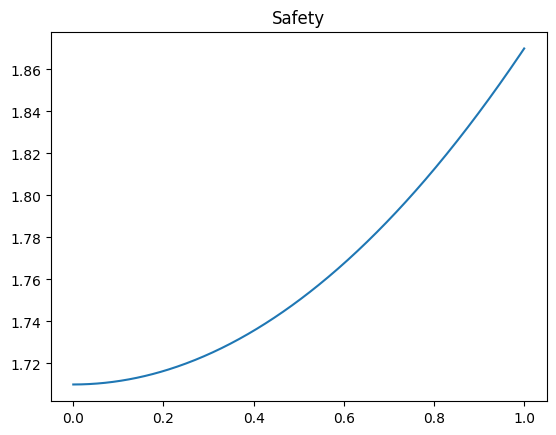

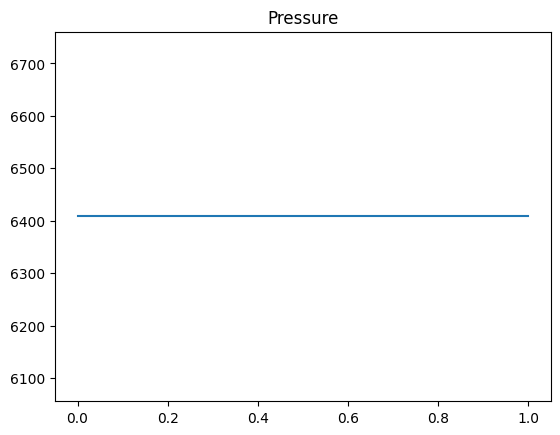

In [3]:
################## 1.3代码块 ##################

plt.figure()
plt.plot(RhoQ,Safety)
plt.title("Safety");

plt.figure()
plt.plot(RhoP,Pressure)
plt.title("Pressure");

### 第二步：拟合安全因子和压强剖面

在 `2.1代码块` 中设置 `iotaMaxOrder` 和 `pressureMaxOrder`，分别控制旋转变换和压强剖面的拟合阶数。

运行后检查拟合曲线和相对误差图。

array([6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408., 6408.,
       6408., 6408.,

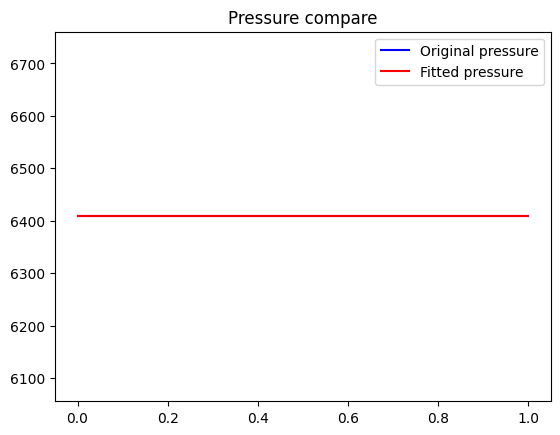

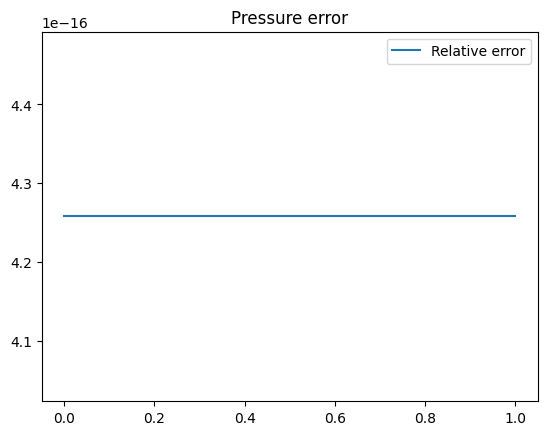

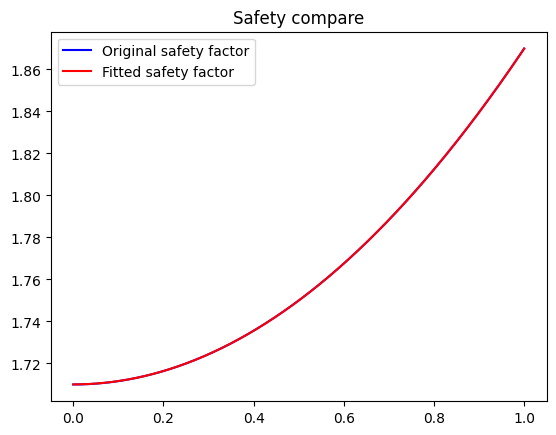

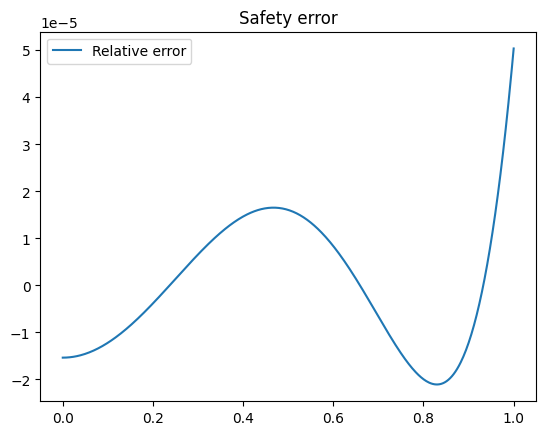

In [8]:
################## 2.1代码块 ##################

iotaMaxOrder = 4;
pressureMaxOrder = 0;

iota = desc.profiles.PowerSeriesProfile().from_values(RhoQ, 1./Safety, iotaMaxOrder, sym=True)
pressure = desc.profiles.PowerSeriesProfile().from_values(RhoP, Pressure, pressureMaxOrder, sym=True)


indexQ = np.zeros((RhoQ.size,3))
indexQ[:,0] = RhoQ

indexP = np.zeros((RhoP.size,3))
indexP[:,0] = RhoP

plt.figure()
plt.plot(RhoP, Pressure, color='blue', label='Original pressure')
plt.plot(
    RhoP,
    np.array(pressure.compute(desc.grid.Grid(indexP))),
    color='red',
    label='Fitted pressure',
)
plt.title("Pressure compare")
plt.legend()

plt.figure()
plt.plot(
    RhoP,
    (Pressure - np.array(pressure.compute(desc.grid.Grid(indexP)))) / Pressure,
    label='Relative error',
)
plt.title("Pressure error")
plt.legend()

plt.figure()
plt.plot(RhoQ, Safety, color='blue', label='Original safety factor')
plt.plot(
    RhoQ,
    1. / np.array(iota.compute(desc.grid.Grid(indexQ))),
    color='red',
    label='Fitted safety factor',
)
plt.title("Safety compare")
plt.legend()

plt.figure()
plt.plot(
    RhoQ,
    (Safety - 1. / np.array(iota.compute(desc.grid.Grid(indexQ)))) / Safety,
    label='Relative error',
)
plt.title("Safety error")
plt.legend()

np.array(pressure.compute(desc.grid.Grid(indexP)))

# indexTest = np.zeros((1000,3))
# RhoTest = np.linspace(0,1,1000)
# indexTest[:,0] = RhoTest

# plt.figure()
# plt.plot(RhoTest,1./np.array(iota.compute(desc.grid.Grid(indexTest))),color='red')
# plt.title("Safety Test");

# plt.figure()
# plt.plot(RhoTest,np.array(pressure.compute(desc.grid.Grid(indexTest))),color='red')
# plt.title("Pressure Test");

### 第三步：设置最外层磁面

在 `3.1代码块` 中设置 `R0`、`a`、`k`、`delta`，分别表示大半径、小半径、拉长比和三角形变。

边界形式为 `R = R0 + a cos(theta + sin(theta) asin(delta))`，`Z = k a sin(theta)`。运行后检查边界拟合图；蓝色为原边界，红色为拟合边界。

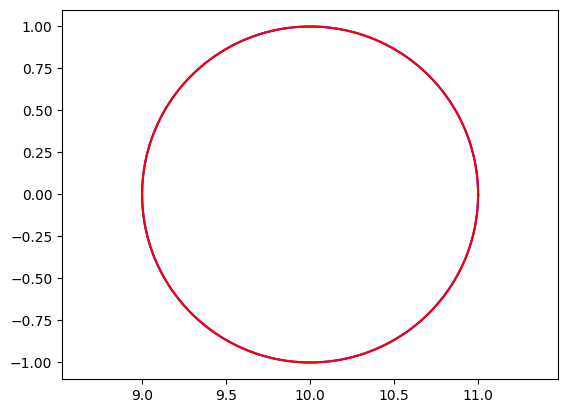

In [9]:
################ 3.1代码块 ##################

R0 = 10;
a = 1;
k = 1;
delta = 0;

theta = np.arange(0,2*np.pi,2*np.pi/1024);
Router = R0+a*np.cos(theta+np.sin(theta)*np.arcsin(delta));
Zouter = k*a*np.sin(theta);

n = len(Router)
Rfft = np.abs(np.fft.fft(Router))/n
Rfft[1:] *= 2
Zfft = np.abs(np.fft.fft(Zouter))/n
Zfft[1:] *= 2

surface = desc.geometry.FourierRZToroidalSurface(
    R_lmn=[Rfft[0],Rfft[1],Rfft[2],Rfft[3]],
    modes_R=[[0, 0], [1, 0], [2, 0], [3, 0]],
    Z_lmn=[-Zfft[1]],
    modes_Z=[[-1, 0]],
)

Router2 = Router.copy();
Router2[:] = 0;
for m in np.arange(0,4,1):
    Router2 = Router2 + Rfft[m]*np.cos(m*theta);

plt.figure();
plt.plot(Router,Zouter,color='blue');
plt.plot(Router2,Zouter,color='red');
plt.axis('equal');

### 第四步：磁通连续求解

本步骤使用磁通连续法求解平衡。做法是先给定目标磁轴磁场 `B0Target`，用它估算环向磁通 `PsiEstimate`，再乘以较大的 `PsiFactor` 得到初始 `Psi`。先在较大的 `Psi` 下求出精度较高的平衡，然后逐步降低 `PsiFactor`，把 `Psi` 推向目标磁轴磁场对应的磁通。

交互式求解的核心循环是：

1. 运行 `4.3代码块`，求解当前 `Psi` 下的平衡。
2. 必要时运行 `4.4代码块`，提高谱分辨率 `M`，再回到 `4.3代码块`。
3. 必要时运行 `4.5代码块`，降低 `PsiFactor` 来调整 `Psi`，再回到 `4.3代码块`。

具体操作建议：

1. 运行 `4.1代码块`：设置 `B0Target` 和初始 `PsiFactor`。`PsiFactor` 是初始磁通相对于估算磁通 `PsiEstimate` 的放大倍数。简单平衡可取 `PsiFactor = 1`；高 beta 或大三角形变平衡建议取 `PsiFactor = 10` 到 `100`，先获得较容易收敛的高磁通平衡。
2. 运行 `4.2代码块`：设置 `initialM` 和 `maxMgrid`，并初始化 DESC 平衡对象。`initialM` 是初始极向谱模数，决定初始解的极向分辨率；`maxMgrid` 是优化力平衡误差时使用的极向网格数。若最外层磁面三角形变较大，建议使用较高的 `maxMgrid`。
3. 运行 `4.3代码块`：设置 `maxIter` 并求解当前 `Psi` 下的平衡。`maxIter` 是本次调用 `eq.solve()` 的最大迭代次数；如果误差还在明显下降，可以继续增大 `maxIter`，重复运行 `4.3代码块`。运行后查看 DESC 输出中的 `Maximum absolute Force error (normalized)`，并检查力误差截面图。
4. 如果当前分辨率下误差下降变慢，运行 `4.4代码块`，把 `newM` 提高后再回到 `4.3代码块` 运行。
5. 如果当前平衡精度已经足够，但磁轴磁场还没有接近 `B0Target`，运行 `4.5代码块`。在其中把 `PsiFactor` 改小，例如从 `100` 改为 `90`、`50`、`20`、`10`、`3`、`1`，然后回到 `4.3代码块` 继续求解。
6. 当 `PsiFactor = 1` 且磁轴磁场、归一化力误差都满足要求时，运行 `4.6代码块` 和 `4.7代码块` 查看最终状态。

`4.3代码块` 到 `4.5代码块` 属于求解过程，可能需要多次交替运行。

In [10]:
################## 4.1代码块 ##################

B0Target = 3
PsiFactor = 1

PsiEstimate = B0Target * np.pi * k * a * a
Psi = PsiFactor * PsiEstimate

print("PsiEstimate =", PsiEstimate)
print("Initial Psi =", Psi)

PsiEstimate = 9.42477796076938
Initial Psi = 9.42477796076938


64
72
FourierZernikeBasis at 0x79da442d2ad0 (L=32, M=16, N=0, NFP=1, sym=False, spectral_indexing=fringe)


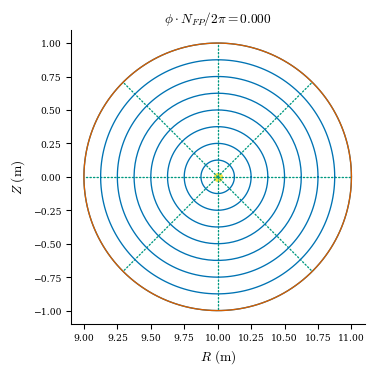

In [ ]:
################## 4.2代码块 ##################

initialM = 16;
maxMgrid = 72;

eq = desc.equilibrium.Equilibrium(
    surface=surface, 
    pressure=pressure,
    iota=iota,
    Psi=Psi,
    NFP=1,
    M=initialM,
    N=0, 
    M_grid=maxMgrid,
    N_grid=0,  
    sym=True,  
    spectral_indexing="fringe",
)
desc.plotting.plot_surfaces(eq);
print(eq.L_grid)
print(eq.M_grid)
print(eq.L_basis)

Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 525 ms
Timer: Objective build = 1.10 sec
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 511 ms
Timer: LinearConstraintProjection build = 3.10 sec
Number of parameters: 784
Number of objectives: 4902
Timer: Initializing the optimization = 4.75 sec

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 1501
Maximum Allowed Total Δx Norm      : inf
Scaled Termination                 : True
Trust Region Method                : qr
Initial Trust 

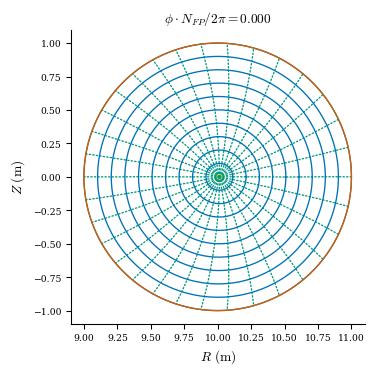

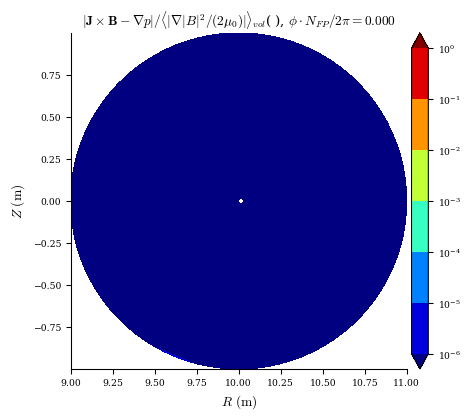

In [12]:
################## 4.3代码块 ##################

maxIter = 300;

eq.solve(
    verbose=3,
    ftol=1e-17,
    xtol=1e-17,
    gtol=1e-17,
    maxiter=maxIter,
);

desc.plotting.plot_surfaces(eq,10,32)
desc.plotting.plot_section(eq, "|F|_normalized", log=True);

In [ ]:
################## 4.4代码块 ##################

newM = 18;
newL = 2*newM;

eq.change_resolution(newL,newM,0,2*newL,maxMgrid,0)

In [ ]:
################## 4.5代码块 ##################

PsiFactor = 90

axisGrid = desc.grid.Grid(np.array([0, 0, 0]))
B0 = eq.compute("|B|", axisGrid)["|B|"][0]

PsiTarget = eq.Psi * B0Target / B0
eq.Psi = PsiFactor * PsiTarget

print("B0        =", B0)
print("B0Target  =", B0Target)
print("PsiFactor =", PsiFactor)
print("PsiTarget =", PsiTarget)
print("New Psi   =", eq.Psi)

In [13]:
################## 4.6代码块 ##################

print(eq.L_grid)
print(eq.M_grid)
print(eq.L_basis)
print(eq.Psi)

64
72
FourierZernikeBasis at 0x79da442d2ad0 (L=32, M=16, N=0, NFP=1, sym=False, spectral_indexing=fringe)
9.42477796076938


In [14]:
################## 4.7代码块 ##################

u0 = 4 * np.pi * 1.0e-7
axisGrid = desc.grid.Grid(np.array([0, 0, 0]))

axisData = eq.compute(["|B|", "R", "Z", "p"], axisGrid)

B0 = axisData["|B|"][0]
Raxis = axisData["R"][0]
Zaxis = axisData["Z"][0]
p0 = axisData["p"][0]
betaAxis = p0 / (B0 * B0 / 2 / u0)

print("B0Target =", B0Target)
print("B0       =", B0)
print("Raxis    =", Raxis)
print("Zaxis    =", Zaxis)
print("Psi      =", eq.Psi)
print("betaAxis =", betaAxis)

B0Target = 3
B0       = 2.9933368843183557
Raxis    = 10.012877824343525
Zaxis    = 1.7748062560513676e-06
Psi      = 9.42477796076938
betaAxis = 0.0017974266164067507


### 第五步：保存平衡文件

保存前建议先运行 `4.6代码块` 和 `4.7代码块`，确认相关物理量满足要求。

在 `5.1代码块` 中设置输出路径并保存平衡文件。文件后缀请保持为 `.hdf5`。

In [ ]:
################## 5.1代码块 ##################

eq.save(r'/mnt/c/Users/Desktop/EQ.hdf5')